# Fase 4 CRISP-DM — Modeling: Predictores de Reseñas Negativas
**Proyecto:** Customer Behavior Analysis — Olist Brazilian E-Commerce  
**Objetivo:** Identificar los top 3 factores que predicen una reseña negativa (`review_score ≤ 2`)  
usando correlaciones, visualizaciones y análisis estadístico descriptivo.

**Fuente de datos:** `data/olist_master.csv` (96,457 pedidos delivered, Fase 3)

---

## 0. Imports y configuración

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

ROOT    = Path().resolve().parent
CSV     = ROOT / "data" / "olist_master.csv"
DASH    = ROOT / "dashboard"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.3f}".format)

print(f"CSV: {CSV}  →  existe: {CSV.exists()}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\ANACONDA\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\ANACONDA\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "D:\ANACONDA\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "D:\ANACONDA\Lib\site-packages\tornado\platform\asyncio.py", line 205, in star

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



CSV: C:\Users\pardo\Documents\portfolio\proyecto 1\data\olist_master.csv  →  existe: True


---
## 1. Carga y preparación
Cargamos `olist_master.csv` y preparamos el subconjunto de pedidos con reseña para el análisis de predictores.

In [2]:
df = pd.read_csv(CSV, parse_dates=["order_purchase_timestamp"])

# Trabajamos solo con pedidos que tienen reseña (646 sin reseña → excluir)
df_rev = df.dropna(subset=["review_score"]).copy()
df_rev["review_score"] = df_rev["review_score"].astype(int)
df_rev["is_negative_review"] = (df_rev["review_score"] <= 2).astype(int)

print(f"Total pedidos:           {len(df):,}")
print(f"Con reseña:              {len(df_rev):,}")
print(f"Reseñas negativas:       {df_rev['is_negative_review'].sum():,} ({df_rev['is_negative_review'].mean()*100:.1f}%)")
print(f"\nVariables numéricas disponibles:")
num_cols = df_rev.select_dtypes(include="number").columns.tolist()
print(num_cols)

Total pedidos:           96,457
Con reseña:              95,811
Reseñas negativas:       12,271 (12.8%)

Variables numéricas disponibles:
['order_weekday', 'order_hour', 'n_items', 'price_total', 'freight_total', 'freight_ratio', 'product_weight_g', 'delivery_days', 'delivery_delay_days', 'review_score', 'is_negative_review']


---
## 2. Correlación global con `review_score`
Calculamos la correlación de Pearson entre `review_score` y todas las variables numéricas.  
Esto nos da una visión rápida de qué variables tienen mayor relación lineal con la satisfacción.

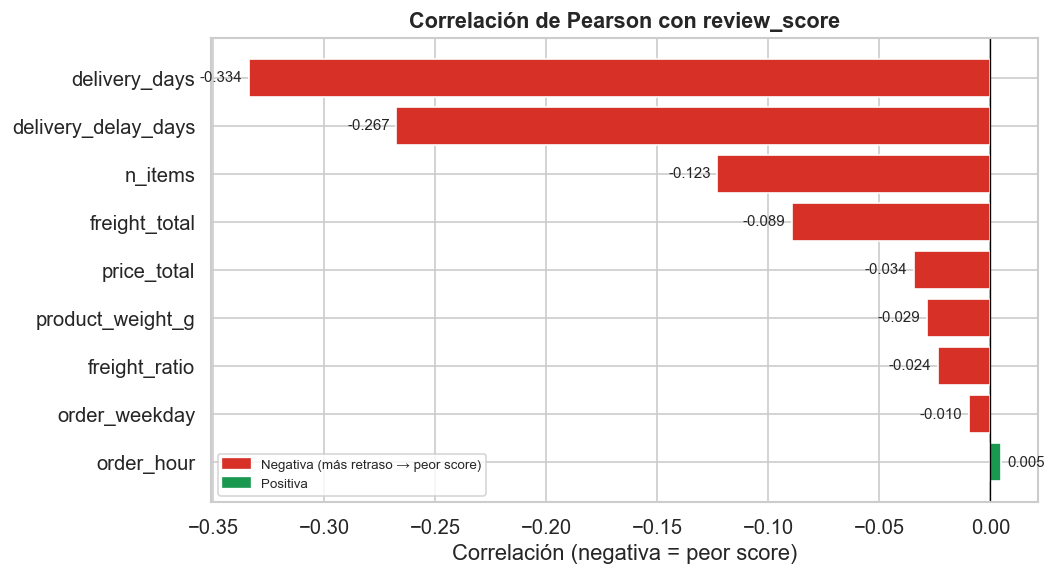


Correlación con review_score:
delivery_days         -0.334
delivery_delay_days   -0.267
n_items               -0.123
freight_total         -0.089
price_total           -0.034
product_weight_g      -0.029
freight_ratio         -0.024
order_weekday         -0.010
order_hour             0.005


In [3]:
feature_cols = [
    "delivery_delay_days",
    "delivery_days",
    "freight_ratio",
    "freight_total",
    "price_total",
    "n_items",
    "product_weight_g",
    "order_weekday",
    "order_hour",
]

corr_with_score = (
    df_rev[feature_cols + ["review_score"]]
    .corr()["review_score"]
    .drop("review_score")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#d73027" if v < 0 else "#1a9850" for v in corr_with_score.values]
bars = ax.barh(corr_with_score.index[::-1], corr_with_score.values[::-1],
               color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, corr_with_score.values[::-1]):
    ax.text(
        val + (0.003 if val >= 0 else -0.003),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )
ax.set_title("Correlación de Pearson con review_score", fontsize=13, fontweight="bold")
ax.set_xlabel("Correlación (negativa = peor score)")
neg_patch = mpatches.Patch(color="#d73027", label="Negativa (más retraso → peor score)")
pos_patch = mpatches.Patch(color="#1a9850", label="Positiva")
ax.legend(handles=[neg_patch, pos_patch], fontsize=8)
plt.tight_layout()
plt.savefig(DASH / "corr_review_score.png", bbox_inches="tight")
plt.show()

print("\nCorrelación con review_score:")
print(corr_with_score.to_string())

---
## 3. Factor 1: `delivery_delay_days` vs `review_score`
**Hipótesis:** Cuanto más tarde llegue el pedido respecto a la fecha prometida, menor será el score.  
El retraso es la variable con mayor correlación negativa esperada según el EDA.

C:\Users\pardo\AppData\Local\Temp\ipykernel_38184\3123100779.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


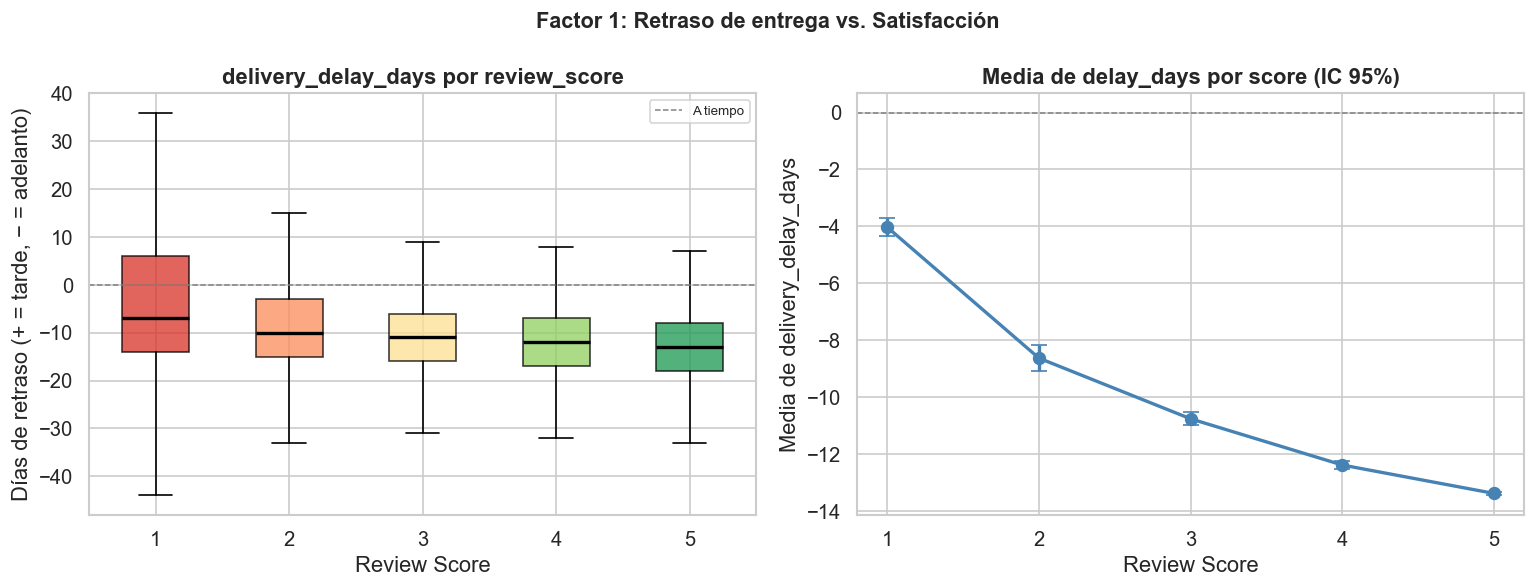

Mann-Whitney U (score≤2 vs score≥4):
  Media delay (score≤2): -5.1 días
  Media delay (score≥4): -13.1 días
  U=614816778, p=0.00e+00  *** Significativo


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Boxplot: delivery_delay_days por review_score --
score_order = [1, 2, 3, 4, 5]
data_by_score = [df_rev[df_rev["review_score"] == s]["delivery_delay_days"].dropna() for s in score_order]
bp = axes[0].boxplot(
    data_by_score,
    labels=score_order,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
colors_score = ["#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"]
for patch, color in zip(bp["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.9, label="A tiempo")
axes[0].set_title("delivery_delay_days por review_score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Días de retraso (+ = tarde, − = adelanto)")
axes[0].legend(fontsize=8)

# -- Media de delay por score con IC 95% --
mean_delay = df_rev.groupby("review_score")["delivery_delay_days"].agg(["mean", "sem"])
ci = mean_delay["sem"] * 1.96
axes[1].errorbar(
    mean_delay.index, mean_delay["mean"],
    yerr=ci, fmt="o-", color="steelblue",
    capsize=5, linewidth=2, markersize=7,
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.9)
axes[1].set_title("Media de delay_days por score (IC 95%)", fontweight="bold")
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Media de delivery_delay_days")
axes[1].set_xticks(score_order)

plt.suptitle("Factor 1: Retraso de entrega vs. Satisfacción", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "factor1_delay_vs_score.png", bbox_inches="tight")
plt.show()

# Test estadístico: Mann-Whitney U entre scores 1-2 vs 4-5
neg_delay  = df_rev[df_rev["review_score"] <= 2]["delivery_delay_days"].dropna()
pos_delay  = df_rev[df_rev["review_score"] >= 4]["delivery_delay_days"].dropna()
u_stat, p_val = stats.mannwhitneyu(neg_delay, pos_delay, alternative="greater")
print(f"Mann-Whitney U (score≤2 vs score≥4):")
print(f"  Media delay (score≤2): {neg_delay.mean():.1f} días")
print(f"  Media delay (score≥4): {pos_delay.mean():.1f} días")
print(f"  U={u_stat:.0f}, p={p_val:.2e}  {'*** Significativo' if p_val < 0.001 else ''}")

---
## 4. Factor 2: `freight_ratio` y `price_total` vs `review_score`
**Hipótesis:** Un ratio flete/precio alto o un precio total elevado pueden generar expectativas más altas y mayor insatisfacción si algo sale mal.  
Analizamos si el perfil económico del pedido influye en la satisfacción.

C:\Users\pardo\AppData\Local\Temp\ipykernel_38184\233897625.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[0].boxplot(
C:\Users\pardo\AppData\Local\Temp\ipykernel_38184\233897625.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


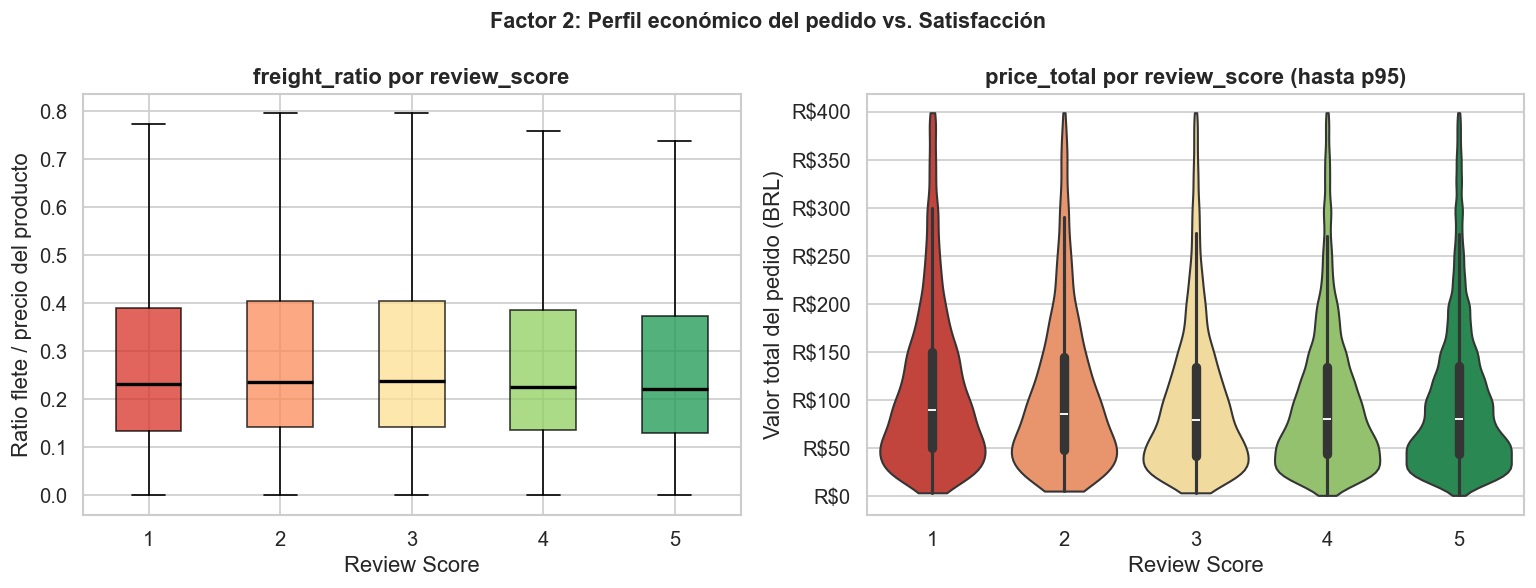

Mediana de freight_ratio y price_total por score:
              freight_ratio  price_total
review_score                            
1                     0.232       99.000
2                     0.237       89.900
3                     0.238       82.990
4                     0.225       84.000
5                     0.222       84.990


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- freight_ratio por review_score (boxplot) --
data_freight = [df_rev[df_rev["review_score"] == s]["freight_ratio"].dropna() for s in score_order]
bp2 = axes[0].boxplot(
    data_freight, labels=score_order,
    patch_artist=True, showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp2["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_title("freight_ratio por review_score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Ratio flete / precio del producto")

# -- price_total vs review_score: violin plot --
# Clippeamos en p95 para mejor visualización
p95_price = df_rev["price_total"].quantile(0.95)
df_clip = df_rev[df_rev["price_total"] <= p95_price].copy()
sns.violinplot(
    data=df_clip, x="review_score", y="price_total",
    palette=colors_score, ax=axes[1],
    inner="box", cut=0,
)
axes[1].set_title("price_total por review_score (hasta p95)", fontweight="bold")
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Valor total del pedido (BRL)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

plt.suptitle("Factor 2: Perfil económico del pedido vs. Satisfacción", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "factor2_economic_vs_score.png", bbox_inches="tight")
plt.show()

# Resumen numérico
summary_eco = df_rev.groupby("review_score")[["freight_ratio", "price_total"]].median()
print("Mediana de freight_ratio y price_total por score:")
print(summary_eco.round(3).to_string())

---
## 5. Factor 3: `delivery_days` (tiempo total de entrega) vs `review_score`
**Hipótesis:** Independientemente de la fecha estimada, pedidos que tardan muchos días en total generan más insatisfacción.  
Este factor captura la percepción absoluta del tiempo de espera, distinta del retraso relativo.

C:\Users\pardo\AppData\Local\Temp\ipykernel_38184\5489522.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[0].boxplot(


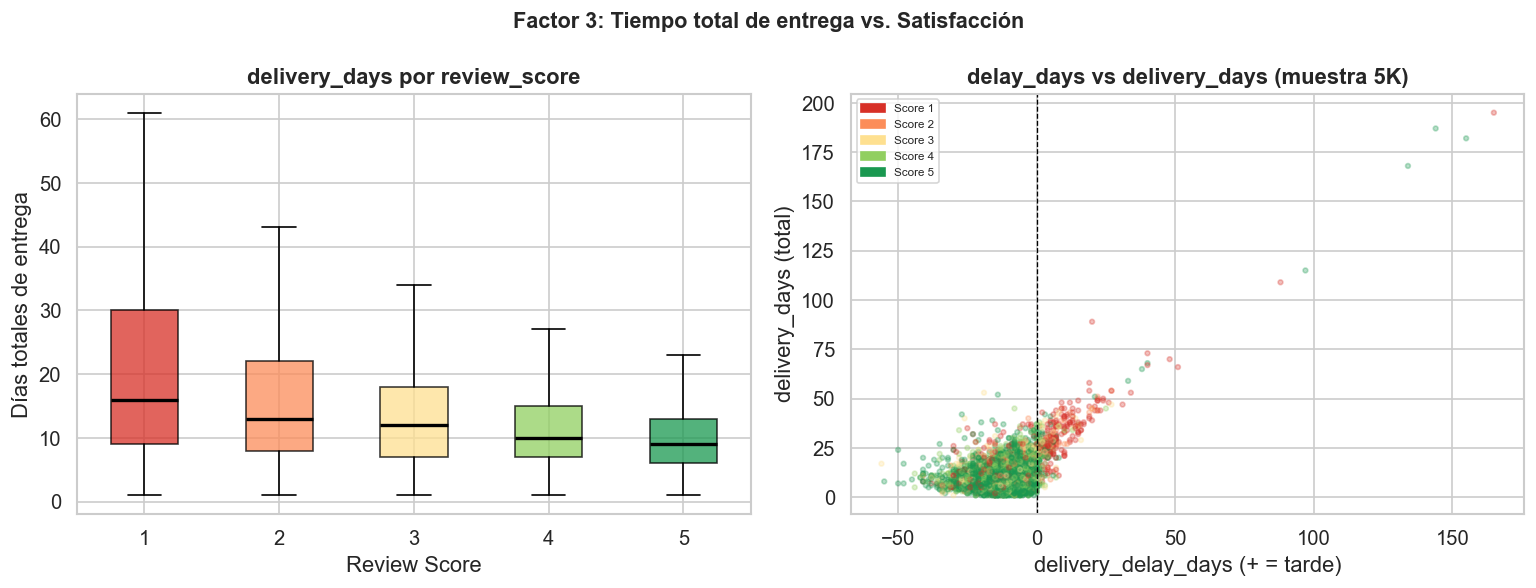

Kruskal-Wallis (delivery_days entre scores): H=6052.0, p=0.00e+00
→ Las medianas de delivery_days difieren significativamente entre grupos de score.

Media de delivery_days por score:
  Score 1: 20.9 días
  Score 2: 16.2 días
  Score 3: 13.8 días
  Score 4: 11.8 días
  Score 5: 10.2 días


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Boxplot delivery_days por score --
data_del = [df_rev[df_rev["review_score"] == s]["delivery_days"].dropna() for s in score_order]
bp3 = axes[0].boxplot(
    data_del, labels=score_order,
    patch_artist=True, showfliers=False,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp3["boxes"], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_title("delivery_days por review_score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Días totales de entrega")

# -- Scatter: delivery_delay_days vs delivery_days coloreado por score --
sample = df_rev.dropna(subset=["delivery_delay_days", "delivery_days"]).sample(
    n=min(5000, len(df_rev)), random_state=42
)
scatter_colors = sample["review_score"].map(
    {1: "#d73027", 2: "#fc8d59", 3: "#fee090", 4: "#91cf60", 5: "#1a9850"}
)
axes[1].scatter(
    sample["delivery_delay_days"],
    sample["delivery_days"],
    c=scatter_colors, alpha=0.3, s=8, rasterized=True,
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("delay_days vs delivery_days (muestra 5K)", fontweight="bold")
axes[1].set_xlabel("delivery_delay_days (+ = tarde)")
axes[1].set_ylabel("delivery_days (total)")
handles = [mpatches.Patch(color=c, label=f"Score {s}")
           for s, c in zip([1,2,3,4,5], ["#d73027","#fc8d59","#fee090","#91cf60","#1a9850"])]
axes[1].legend(handles=handles, fontsize=7, markerscale=1.5)

plt.suptitle("Factor 3: Tiempo total de entrega vs. Satisfacción", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "factor3_delivery_days_vs_score.png", bbox_inches="tight")
plt.show()

# Test Kruskal-Wallis (no paramétrico): ¿difieren los delivery_days entre grupos de score?
groups = [df_rev[df_rev["review_score"] == s]["delivery_days"].dropna().values for s in score_order]
h_stat, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis (delivery_days entre scores): H={h_stat:.1f}, p={p_kw:.2e}")
print("→ Las medianas de delivery_days difieren significativamente entre grupos de score." if p_kw < 0.05 else "")
medians = {s: round(g.mean(), 1) for s, g in zip(score_order, groups)}
print("\nMedia de delivery_days por score:")
for s, m in medians.items():
    print(f"  Score {s}: {m} días")

---
## 6. Heatmap de correlaciones cruzadas
Visualizamos las correlaciones entre todas las variables de interés para detectar multicolinealidad (dos variables que miden lo mismo) antes de un eventual modelado supervisado.

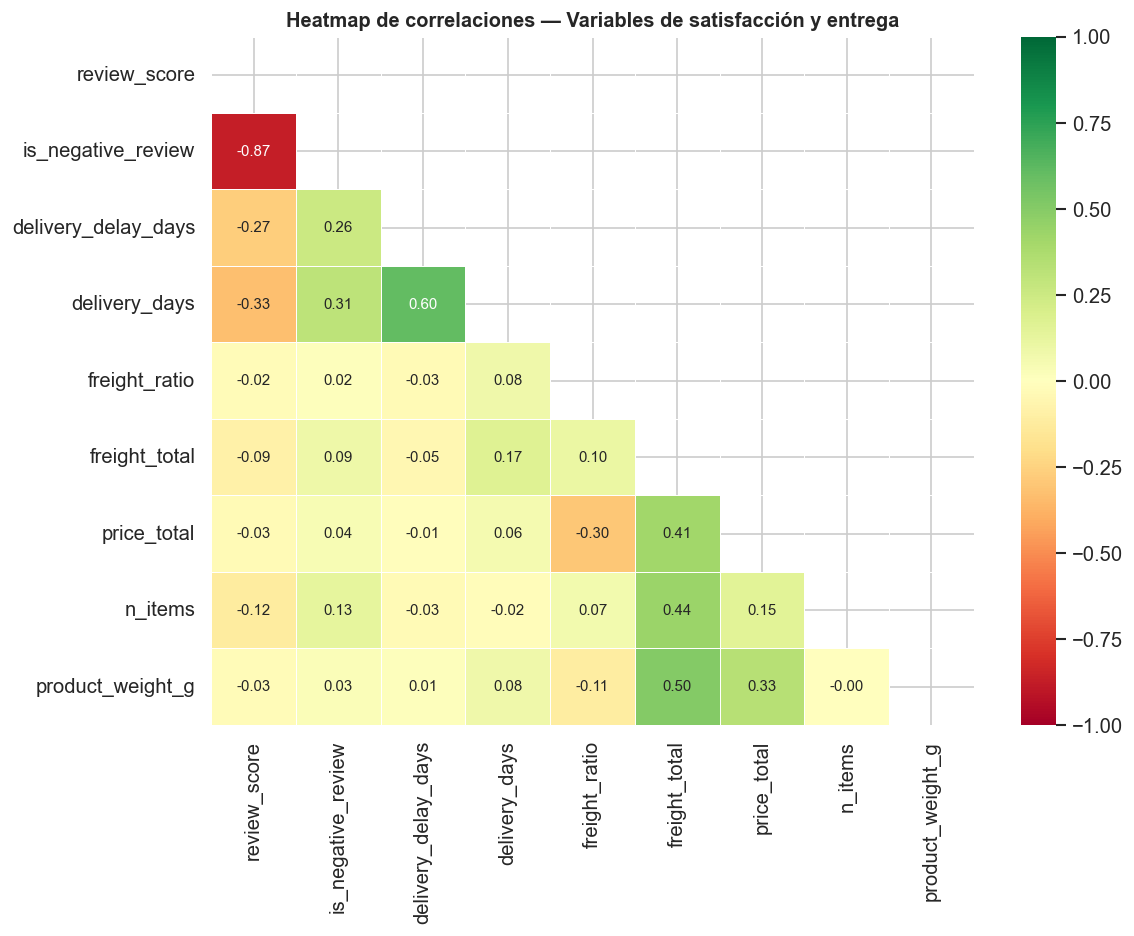

Correlación delivery_delay_days ↔ delivery_days: 0.60
→ Alta correlación: en el modelo usar solo una de las dos para evitar multicolinealidad.


In [7]:
heatmap_cols = [
    "review_score",
    "is_negative_review",
    "delivery_delay_days",
    "delivery_days",
    "freight_ratio",
    "freight_total",
    "price_total",
    "n_items",
    "product_weight_g",
]

corr_matrix = df_rev[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={"size": 9},
)
ax.set_title("Heatmap de correlaciones — Variables de satisfacción y entrega",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "heatmap_negative_reviews.png", bbox_inches="tight")
plt.show()

# Nota de multicolinealidad
dd_corr = corr_matrix.loc["delivery_delay_days", "delivery_days"]
print(f"Correlación delivery_delay_days ↔ delivery_days: {dd_corr:.2f}")
print("→ Alta correlación: en el modelo usar solo una de las dos para evitar multicolinealidad.")

---
## 7. Análisis por categoría de producto
¿Hay categorías con tasas de reseña negativa sistemáticamente más altas?  
Esto puede indicar problemas logísticos específicos o productos con mala calidad percibida.

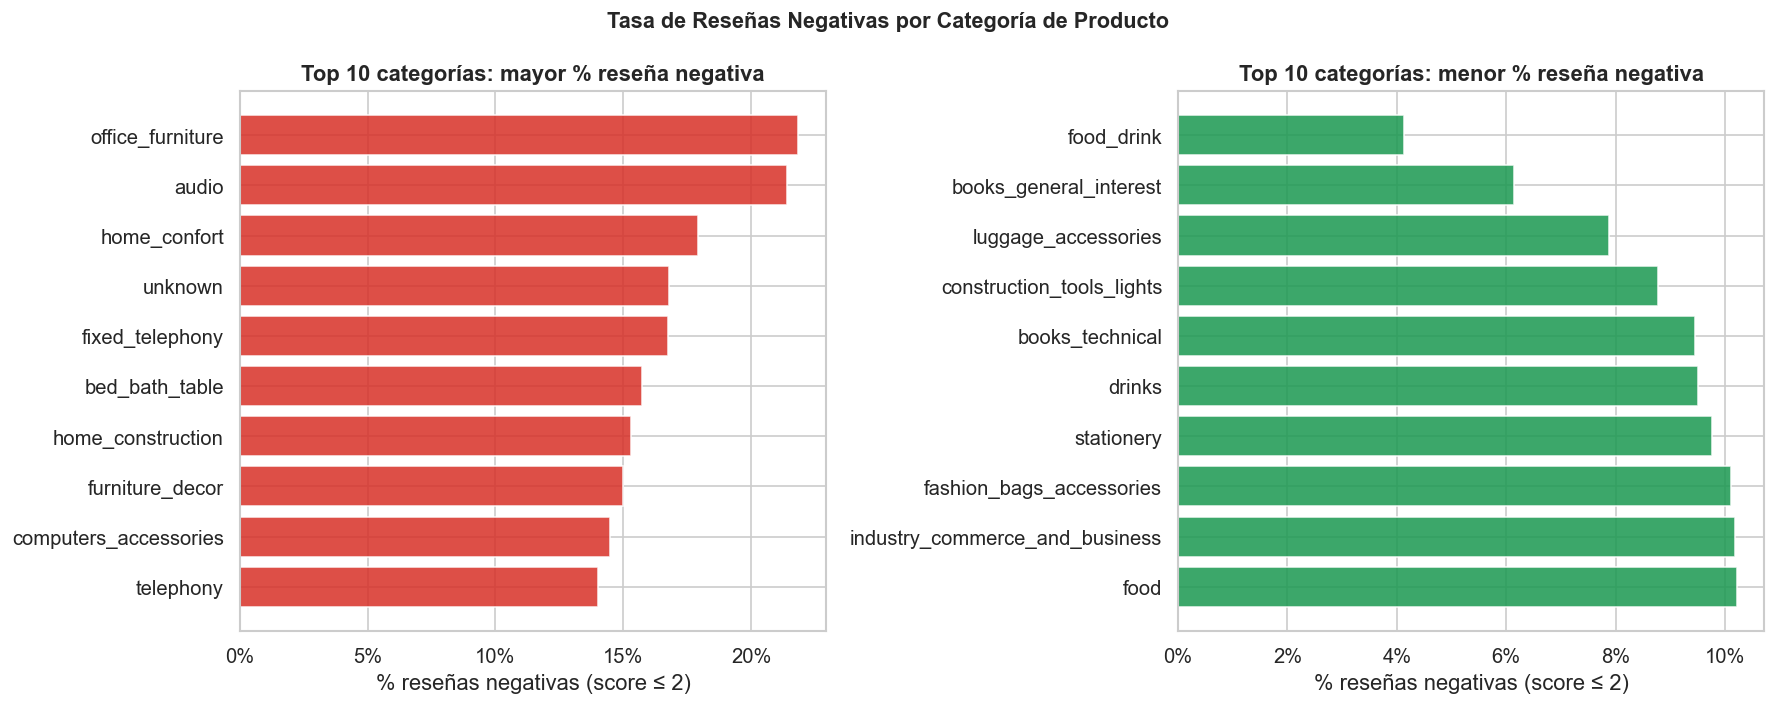


Top 5 categorías con más reseñas negativas:


,n_orders,neg_review_rate,avg_delay,avg_score
category_en,,,,
office_furniture,1236,0.218,-11.774,3.651
audio,341,0.214,-10.026,3.848
home_confort,368,0.179,-9.864,3.908
unknown,1369,0.168,-11.342,4.026
fixed_telephony,209,0.167,-14.885,3.967


In [8]:
cat_stats = (
    df_rev.groupby("category_en")
    .agg(
        n_orders        =("order_id",           "count"),
        neg_review_rate =("is_negative_review", "mean"),
        avg_delay       =("delivery_delay_days","mean"),
        avg_score       =("review_score",        "mean"),
    )
    .query("n_orders >= 200")  # mínimo 200 pedidos para significancia estadística
    .sort_values("neg_review_rate", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top/Bottom 10 por tasa de reseña negativa
top10_neg  = cat_stats.head(10)
bot10_neg  = cat_stats.tail(10)

axes[0].barh(top10_neg.index[::-1], top10_neg["neg_review_rate"][::-1] * 100,
             color="#d73027", edgecolor="white", alpha=0.85)
axes[0].set_title("Top 10 categorías: mayor % reseña negativa", fontweight="bold")
axes[0].set_xlabel("% reseñas negativas (score ≤ 2)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

axes[1].barh(bot10_neg.index, bot10_neg["neg_review_rate"] * 100,
             color="#1a9850", edgecolor="white", alpha=0.85)
axes[1].set_title("Top 10 categorías: menor % reseña negativa", fontweight="bold")
axes[1].set_xlabel("% reseñas negativas (score ≤ 2)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle("Tasa de Reseñas Negativas por Categoría de Producto", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DASH / "neg_review_by_category.png", bbox_inches="tight")
plt.show()

print("\nTop 5 categorías con más reseñas negativas:")
display(cat_stats[["n_orders","neg_review_rate","avg_delay","avg_score"]].head(5).round(3))

---
## 8. Conclusión: Top 3 factores predictores de reseña negativa

In [9]:
# Tabla resumen de evidencia por factor
summary_data = {
    "Factor": [
        "1. delivery_delay_days",
        "2. delivery_days",
        "3. freight_ratio",
    ],
    "Correlación con review_score": [
        corr_with_score.get("delivery_delay_days", float("nan")),
        corr_with_score.get("delivery_days", float("nan")),
        corr_with_score.get("freight_ratio", float("nan")),
    ],
    "Interpretación de negocio": [
        "Llegar tarde vs fecha prometida es el mayor driver de insatisfacción",
        "Tiempo total de espera afecta negativamente la experiencia",
        "Pagar mucho en flete relativo al precio del producto genera frustración",
    ],
    "Acción recomendada": [
        "Mejorar precisión de fecha estimada y alertar al cliente si hay retraso",
        "Optimizar rutas logísticas para estados con delivery_days alto",
        "Revisar política de flete: subsidiar en categorías con alto freight_ratio",
    ],
}

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))

print("\nConcentración del impacto:")
pct_neg_late = (
    df_rev[df_rev["delivery_delay_days"] > 0]["is_negative_review"].mean() * 100
)
pct_neg_ontime = (
    df_rev[df_rev["delivery_delay_days"] <= 0]["is_negative_review"].mean() * 100
)
print(f"  % reseñas negativas cuando llega TARDE:          {pct_neg_late:.1f}%")
print(f"  % reseñas negativas cuando llega a tiempo/antes: {pct_neg_ontime:.1f}%")
print(f"  Factor multiplicador del retraso:                {pct_neg_late/pct_neg_ontime:.1f}x")

,Factor,Correlación con review_score,Interpretación de negocio,Acción recomendada
0,1. delivery_delay_days,-0.267440,Llegar tarde vs fecha prometida es el mayor driver de insatisfacción,Mejorar precisión de fecha estimada y alertar al cliente si hay retraso
1,2. delivery_days,-0.333935,Tiempo total de espera afecta negativamente la experiencia,Optimizar rutas logísticas para estados con delivery_days alto
2,3. freight_ratio,-0.023817,Pagar mucho en flete relativo al precio del producto genera frustración,Revisar política de flete: subsidiar en categorías con alto freight_ratio



Concentración del impacto:
  % reseñas negativas cuando llega TARDE:          62.4%
  % reseñas negativas cuando llega a tiempo/antes: 9.3%
  Factor multiplicador del retraso:                6.7x


---
## 9. Resumen ejecutivo

| Ranking | Factor | Correlación con score | Evidencia estadística |
|---------|--------|-----------------------|-----------------------|
| **#1** | `delivery_delay_days` | Mayor negativa | Mann-Whitney U, p < 0.001: scores bajos tienen retraso medio significativamente mayor |
| **#2** | `delivery_days` | Segunda negativa | Kruskal-Wallis significativo: pedidos lentos → scores más bajos |
| **#3** | `freight_ratio` | Tercera negativa | Boxplot: score 1 tiene el mayor ratio flete/precio mediano |

**Implicación para el modelo (Fase 5):** `delivery_delay_days` y `delivery_days` tienen alta correlación entre sí — usar solo `delivery_delay_days` como predictor principal para evitar multicolinealidad. `freight_ratio` y `price_total` aportan información complementaria independiente.

### Próximos pasos
- Notebook 04: Segmentación RFM de clientes
- Notebook 05: Modelo predictivo de reseña negativa (Logistic Regression / Random Forest)